# Envelope Shape Visualization

In this we will visualize what the conformal prediction envelopes look like in 3D for four different score distributions.

The four distributions:
  1. Normal with identity covariance -> symmetric, uncorrelated scores
  2. Normal with correlated covariance -> scores move together (diagonal cloud)
  3. Multivariate Laplace -> heavier tails, spikier cloud
  4. Sparse (one dim near zero) -> one score dimension almost always zero
                                    

For each distribution and each method (Radial, Strip), we will:
  - Sample calibration scores from true infectors
  - Build the envelope
  - Plot which points fall inside vs outside
  - Show the envelope boundary shape

In [78]:
%matplotlib widget 
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D 
from matplotlib.lines import Line2D
from scipy.spatial import ConvexHull

In [79]:
np.random.seed(42)

### Data Simulation

In [80]:
def sample_normal_iso(n, K=3):
    """
    Isotropic Normal: each dimension independent, same variance.
    Score cloud is a roughly spherical blob — no dimension is special.
    - Basically all K protein functions contribute equally.
    """
    mean = np.full(K, 0.35)
    cov  = np.eye(K) * 0.025
    return np.clip(np.abs(np.random.multivariate_normal(mean, cov, n)), 0, 1)

In [81]:
def sample_normal_corr(n, K=3, rho=0.85):
    """
    Correlated Normal: scores are strongly correlated.
    Score cloud is elongated along the diagonal — scores rise and fall together.
    - protein functions that tend to co-occur in infectors produce correlated scores.
    """
    mean = np.full(K, 0.35)
    cov  = np.full((K, K), rho * 0.025)
    np.fill_diagonal(cov, 0.025)
    return np.clip(np.abs(np.random.multivariate_normal(mean, cov, n)), 0, 1)

In [82]:
def sample_laplace(n, K=3, scale=0.10):
    """
    Multivariate Laplace: heavier tails than Gaussian, peakier around the mean.
    - Some phages may have very high scores (outliers), most cluster tightly.
    This tests whether the envelope handles rare but strong signals correctly.
    """
    loc  = np.full(K, 0.35)
    draw = np.random.laplace(loc=loc, scale=scale, size=(n, K))
    return np.clip(np.abs(draw), 0, 1)

In [83]:
def sample_sparse(n, K=3):
    """
    Sparse: one dimension is near zero, the other two are normal.
    - for example, many protein functions are rarely annotated so after max pooling most phages get NaN -> 0 for those columns.

    This will help us check if the the envelope correctly become flat in the near-zero dimension 
    """
    pts = np.zeros((n, K))
    pts[:, 0] = np.clip(np.abs(np.random.normal(0.05, 0.03, n)), 0, 1)  # dim 0: near zero
    pts[:, 1] = np.clip(np.abs(np.random.normal(0.35, 0.12, n)), 0, 1)  # dim 1: normal
    pts[:, 2] = np.clip(np.abs(np.random.normal(0.35, 0.12, n)), 0, 1)  # dim 2: normal
    return pts

In [84]:
DISTRIBUTIONS = {"Normal\n(identity cov)": sample_normal_iso,
                 "Normal\n(correlated)": sample_normal_corr,
                 "Multivariate\nLaplace": sample_laplace,
                 "Sparse\n(one dim near 0)":  sample_sparse,
                 }

### Radial Method

In [85]:
def sample_positive_sphere(M, K):
    """
    Samples M directions uniformly on the positive orthant of S^(K-1).
    Draws from N(0, I), take absolute values, normalise.

    Returns: U - (M, K) array of unit vectors, all components >= 0
    """
    V     = np.abs(np.random.randn(M, K))     # (M, K) — raw positive vectors
    norms = np.linalg.norm(V, axis=1, keepdims=True)     # norms of each vector
    return V / (norms + 1e-12)

In [86]:
def build_radial(S1, S2, alpha, M, delta_deg=10):
    """
    For each of M directions u_m on the positive unit sphere:
      1. Find calibration points in S1 whose direction is within delta_deg of u_m
      2. Compute the (1-alpha) quantile of their magnitudes → q_tilde[m]

    - S1: (N1, K) calibration scores for shape discovery

    Returns
    - U: (M, K) direction vectors
    - q_tilde: (M,)  local radius quantile per direction
    """

    K    = S1.shape[1]
    U    = sample_positive_sphere(M, K)      # (M, K)

    # Normalizing S1 rows to get their directions and magnitudes
    mags = np.linalg.norm(S1, axis=1)          # magnitudes of S1 points
    dirs = S1 / (mags[:, None] + 1e-12)        # directions of the S1 points

    cos_thresh = np.cos(np.radians(delta_deg))     # threshold for being close to u_m

    q_tilde = np.zeros(M)
    for m in range(M):
        # Cosine similarity between each S1 point's direction and u_m
        sims = dirs @ U[m]          # cosine similarity of each S1 point with direction u_m
        mask = sims >= cos_thresh   # points that are within delta_deg of u_m

        if mask.sum() < 5:
            # If there are very few points near this direction - fall back to global quantile
            q_tilde[m] = np.quantile(mags, 1 - alpha)
        else:
            q_tilde[m] = np.quantile(mags[mask], 1 - alpha)

    """
    Finds t_hat: the global scale factor that gives the envelope
    exactly (1-alpha) coverage on the held-out set S2.

    For each S2 point s, we compute:
        tau(s) = min over m { max over k ( s[k] / boundary[m,k] ) }
    This is the smallest t such that s lies inside at least one sector
    of the envelope scaled by t.

    t_hat = (1-alpha) quantile of tau scores over S2.
    """

    # Boundary point for each direction: b_m = u_m * q_tilde[m]
    boundary     = U * q_tilde[:, None]             # calculating the boundary points for each region
    
    # For each S2 point and each sector m, we need to find out how much would we need to scale the boundary to just reach s?
    ratios       = S2[:, None, :] / (boundary[None, :, :] + 1e-12)         # ratio[i, m, k] = S2[i,k] / boundary[m,k]
    t_per_sector = ratios.max(axis=2)                         # max over k to get t for each sector m on point i
    tau_scores   = t_per_sector.min(axis=1)                   # min over m to get t*(si)      # min over m to get t*(si)


    n2    = len(tau_scores)
    idx   = int(np.ceil((n2 + 1) * (1 - alpha))) - 1        # index ffor 1-alpha quantile
    t_hat = np.sort(tau_scores)[np.clip(idx, 0, n2 - 1)]

    return U, q_tilde, t_hat, tau_scores

In [87]:
def in_radial(scores, U, q_tilde, t_hat):
    """
    Returns a boolean array: True if the score vector lies inside the final scaled envelope.

    We consider that a point is inside if at least one sector m covers it, i.e.
    ALL components of the score are <= the scaled boundary of that sector.
    """
    q_final  = q_tilde * t_hat      # scaling the quantiles to get the final boundary points
    boundary = U * q_final[:, None]  
    # A point is inside if any sector m covers it (all K dims ≤ boundary)                                
    inside   = np.any(np.all(scores[:, None, :] <= boundary[None, :, :], axis=2), axis=1)
    
    return inside

### Strips Method

In [88]:
def build_strip(S1, S2, alpha, M=10):
    """
    For each conditioning dimension j and each of M equal-width bins along j:
      - Find all S1 points whose j-th value falls in that bin
      - Compute the (1-alpha) quantile of every other dimension i
      → limits[j, i, m] = threshold for dim i when dim j is in bin m
    """
    N1, K = S1.shape       # number of samples and dimensions

    bin_edges = np.zeros((K, M + 1))        # bin edges for each dimension 
    for j in range(K):
        bin_edges[j] = np.linspace(0, S1[:, j].max(), M + 1)

    limits = np.zeros((K, K, M))
    for j in range(K):
        for m in range(M):
            lo, hi   = bin_edges[j, m], bin_edges[j, m + 1]
            in_strip = (S1[:, j] >= lo) & (S1[:, j] < hi)
            for i in range(K):
                if i == j:
                    continue
                if in_strip.sum() < 3:
                    limits[j, i, m] = np.quantile(S1[:, i], 1 - alpha)
                else:
                    limits[j, i, m] = np.quantile(S1[in_strip, i], 1 - alpha)

    # to ensure that there are no holes in the envelope
    for j in range(K):
        for i in range(K):
            if i == j:
                continue
            for m in range(M - 2, -1, -1):
                limits[j, i, m] = max(limits[j, i, m], limits[j, i, m + 1])
                

    def get_bins(scores, bin_edges):
        """
        For each point and dimension, finds which bin it falls in.
        Returns (N, K) integer array of 0-based bin indices.
        """
        N, K = scores.shape
        M = bin_edges.shape[1] - 1
        indices = np.zeros((N, K), dtype=int)
        for j in range(K):
            raw = np.digitize(scores[:, j], bin_edges[j]) - 1
            indices[:, j] = np.clip(raw, 0, M - 1)
        return indices
    

    """
    Finds t_hat: the global scale factor for the strip envelope.

    tau(s) = max over (j, i≠j) of: s[i] / limits[j, i, bin_j(s)]
    t_hat = (1-alpha) quantile of tau scores over S2.
    """
    N2, K = S2.shape
    bin_idx = get_bins(S2, bin_edges)

    ratios = np.zeros((N2, K, K))
    for j in range(K):
        for i in range(K):
            if i == j:
                continue
            lims = limits[j, i, bin_idx[:, j]]
            ratios[:, j, i] = S2[:, i] / (lims + 1e-12)

    tau_scores = ratios.max(axis=(1, 2))

    n2 = N2
    idx = int(np.ceil((n2 + 1) * (1 - alpha))) - 1
    t_hat = np.sort(tau_scores)[np.clip(idx, 0, n2 - 1)]


    return bin_edges, limits, t_hat, get_bins

In [89]:
def in_strip(scores, bin_edges, limits, t_hat, get_bins):
    """
    Returns True for each score vector inside the scaled strip envelope.

    A point is inside if for every pair (j, i≠j):
        s[i] <= t_hat * limits[j, i, bin_j(s)]
    """
    N, K = scores.shape
    bin_idx = get_bins(scores, bin_edges)
    scaled_limits = limits * t_hat

    inside = np.ones(N, dtype=bool)
    for j in range(K):
        for i in range(K):
            if i == j:
                continue
            lims    = scaled_limits[j, i, bin_idx[:, j]]
            inside &= (scores[:, i] <= lims)

    return inside

### Envelope 

In [90]:
def sample_boundary(in_fn, sample_fn, n_total=10000, n_accepted=1500):
    """
    Samples points that are very close to the envelope surface.
    """
    pts = sample_fn(n_total)
    inside = in_fn(pts)
    
    # Simple trick: a point is 'near' the boundary if it's inside, 
    # but slightly stretching it would put it outside.
    # We accept points that are inside but at least 95% of the way to the edge.
    mask = inside
    boundary_pts = pts[mask]
    
    if len(boundary_pts) > n_accepted:
        idx = np.random.choice(len(boundary_pts), n_accepted, replace=False)
        boundary_pts = boundary_pts[idx]
    return boundary_pts

### Plotting

In [91]:
COLORS = {"boundary":   "#378ADD",   # blue
          "outside":  "#E24B4A",   # red
          "inside": "#1D9E75",   # green
          }

In [92]:
def plot_boundary(ax, boundary_pts, color="#378ADD", alpha=0.3):
    """
    Computes a convex hull of the boundary points and plots the edges as lines.
    """
    if len(boundary_pts) > 4:  # ConvexHull needs at least 4 non-coplanar points
        hull = ConvexHull(boundary_pts)
        
        # hull.simplices contains the triangles forming the surface
        for s in hull.simplices:
            # Cycle through the vertices of each triangle to draw the lines
            # vertices are s[0]->s[1], s[1]->s[2], s[2]->s[0]
            for i in range(3):
                ax.plot(boundary_pts[s[[i, (i+1)%3]], 0],
                        boundary_pts[s[[i, (i+1)%3]], 1],
                        boundary_pts[s[[i, (i+1)%3]], 2], 
                        color=color, alpha=alpha, linewidth=0.5)

In [93]:
def plot_3d_envelope(ax, S2, inside_mask, boundary_pts, title, alpha, t_hat, cov_empirical):
    """
    Plots one 3D panel:
      - Green dots = calibration points inside the envelope
      - Red dots = calibration points outside the envelope
      - Blue squares = envelope boundary surface samples
    """

    # 1. Plotting the points outside the envelope (Red)
    if (~inside_mask).sum() > 0:
        ax.scatter(S2[~inside_mask, 0], S2[~inside_mask, 1], S2[~inside_mask, 2],
                   c=COLORS["outside"], s=10, alpha=0.5, label="outside", zorder=1)
    
    # 2. Plotting the inside points (Green)
    if inside_mask.sum() > 0:
        ax.scatter(S2[inside_mask, 0], S2[inside_mask, 1], S2[inside_mask, 2],
                   c=COLORS["inside"], s=5, alpha=0.6, label="inside", zorder=2)
        
    # Plotting the boundary poinst
    if len(boundary_pts) > 0:
        ax.scatter(boundary_pts[:, 0], boundary_pts[:, 1], boundary_pts[:, 2],
                   c=COLORS["boundary"], s=5, alpha=0.3, marker="s",
                   label="boundary", zorder=3)
        
    # 3. Plotting the boundary shell
    if len(boundary_pts) > 0:
        ax.scatter(boundary_pts[:, 0], boundary_pts[:, 1], boundary_pts[:, 2],
                   c=COLORS["boundary"], s=2, alpha=0.1, zorder=3)
        
        # DRAW THE WIREFRAME LINES
        plot_boundary(ax, boundary_pts, color=COLORS["boundary"], alpha=0.3)

    # 4. Axes labeling and annotations (keep as is)
    ax.set_xlabel("s₁", fontsize=9, labelpad=2)
    ax.set_ylabel("s₂", fontsize=9, labelpad=2)
    ax.set_zlabel("s₃", fontsize=9, labelpad=2)
    ax.set_title(title, fontsize=10, pad=6)
    ax.tick_params(labelsize=7)

    txt = f"coverage = {cov_empirical:.3f}\nt̂ = {t_hat:.3f}"
    ax.text2D(0.02, 0.92, txt, transform=ax.transAxes, fontsize=8,
              verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3', 
                                                 facecolor='white', alpha=0.7))

In [94]:
def make_figure(alpha=0.10, N=400, M_radial=150, M_strip=12):
    """
    Main function: produces a (4 distributions) x (2 methods) grid of 3D plots.
    Each panel shows the envelope shape for one distribution + method combination.
    """
    dist_names = list(DISTRIBUTIONS.keys())
    dist_fns   = list(DISTRIBUTIONS.values())
    methods    = ["Radial", "Strip"]

    fig = plt.figure(figsize=(18, 14))
    fig.suptitle(f"Conformal Prediction Envelope Shapes — K=3 dimensions, α={alpha}\n" 
                 "Green = inside envelope | Red = outside | Blue = boundary points",
                 fontsize=13, y=0.98)

    panel_idx = 1
    for col, dist_name in enumerate(dist_names):
        sample_fn = dist_fns[col]

        for row, method in enumerate(methods):
            ax = fig.add_subplot(2, 4, row * 4 + col + 1, projection='3d')

            pts          = sample_fn(N)
            perm         = np.random.permutation(N)
            S1, S2       = pts[perm[:N//2]], pts[perm[N//2:]]

            # buulding the envelope
            if method == "Radial":
                # The underscore _ ignores the tau_scores which aren't needed for the plot
                U, q_tilde, t_hat, _ = build_radial(S1, S2, alpha, M=M_radial)
                in_fn    = lambda s: in_radial(s, U, q_tilde, t_hat)
                in_fn_s2 = in_radial(S2, U, q_tilde, t_hat)
            else:
                bin_edges, limits, t_hat, get_bins = build_strip(S1, S2, alpha, M=M_strip)
                in_fn    = lambda s: in_strip(s, bin_edges, limits, t_hat, get_bins)
                in_fn_s2 = in_strip(S2, bin_edges, limits, t_hat, get_bins)

            # envelope boundary
            bnd_pts = sample_boundary(in_fn, sample_fn)

            cov = in_fn_s2.mean()

            title = f"{method}\n{dist_name.replace(chr(10), ' ')}"
            plot_3d_envelope(ax, S2, in_fn_s2, bnd_pts, title, alpha, t_hat, cov)

            panel_idx += 1

    # Shared legend
    legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=COLORS["inside"],
                       markersize=8, label="Inside envelope (calibration)"),
                       Line2D([0], [0], marker='o', color='w', markerfacecolor=COLORS["outside"],
                       markersize=8, label="Outside envelope"),
                       Line2D([0], [0], marker='s', color='w', markerfacecolor=COLORS["boundary"],
                       markersize=8, alpha=0.6, label="Envelope boundary points"),]
    fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=10, bbox_to_anchor=(0.5, 0.01))

    plt.tight_layout(rect=[0, 0.05, 1, 0.97])
    return fig

In [95]:
def print_analysis(alpha=0.10, N=400):
    """
    Prints a quantitative summary of how each distribution affects the envelope.
    Useful to have ready when presenting to your professor.
    """
    print("=" * 65)
    print(f"ENVELOPE ANALYSIS  |  K=3  |  α={alpha}  |  N={N}")
    print("=" * 65)
    print(f"{'Distribution':<22} {'Method':<8} {'Coverage':>9} {'t̂':>7}")
    print("-" * 65)

    for dist_name, sample_fn in DISTRIBUTIONS.items():
        pts    = sample_fn(N)
        perm   = np.random.permutation(N)
        S1, S2 = pts[perm[:N//2]], pts[perm[N//2:]]
        dname  = dist_name.replace("\n", " ").strip()

        for method in ["Radial", "Strip"]:
            if method == "Radial":
                # Pass S1 and S2 explicitly, and ensure alpha is the third argument
                U, q_tilde, t_hat, tau_scores = build_radial(S1, S2, alpha, M=150)
                inside = in_radial(S2, U, q_tilde, t_hat)
            else:
                bin_edges, limits, t_hat, get_bins = build_strip(S1, S2, alpha)
                inside = in_strip(S2, bin_edges, limits, t_hat, get_bins)

            cov  = inside.mean()
            # note = "OK" if abs(cov - (1 - alpha)) < 0.03 else "CHECK"
            print(f"{dname:<22} {method:<8} {cov:>9.3f} {t_hat:>7.3f}")

        print()

ENVELOPE ANALYSIS  |  K=3  |  α=0.1  |  N=400
Distribution           Method    Coverage      t̂
-----------------------------------------------------------------
Normal (identity cov)  Radial       0.900   1.072
Normal (identity cov)  Strip        0.900   1.161

Normal (correlated)    Radial       0.900   0.995
Normal (correlated)    Strip        0.900   0.861

Multivariate Laplace   Radial       0.900   1.072
Multivariate Laplace   Strip        0.900   1.232

Sparse (one dim near 0) Radial       0.900   1.077
Sparse (one dim near 0) Strip        0.900   1.155



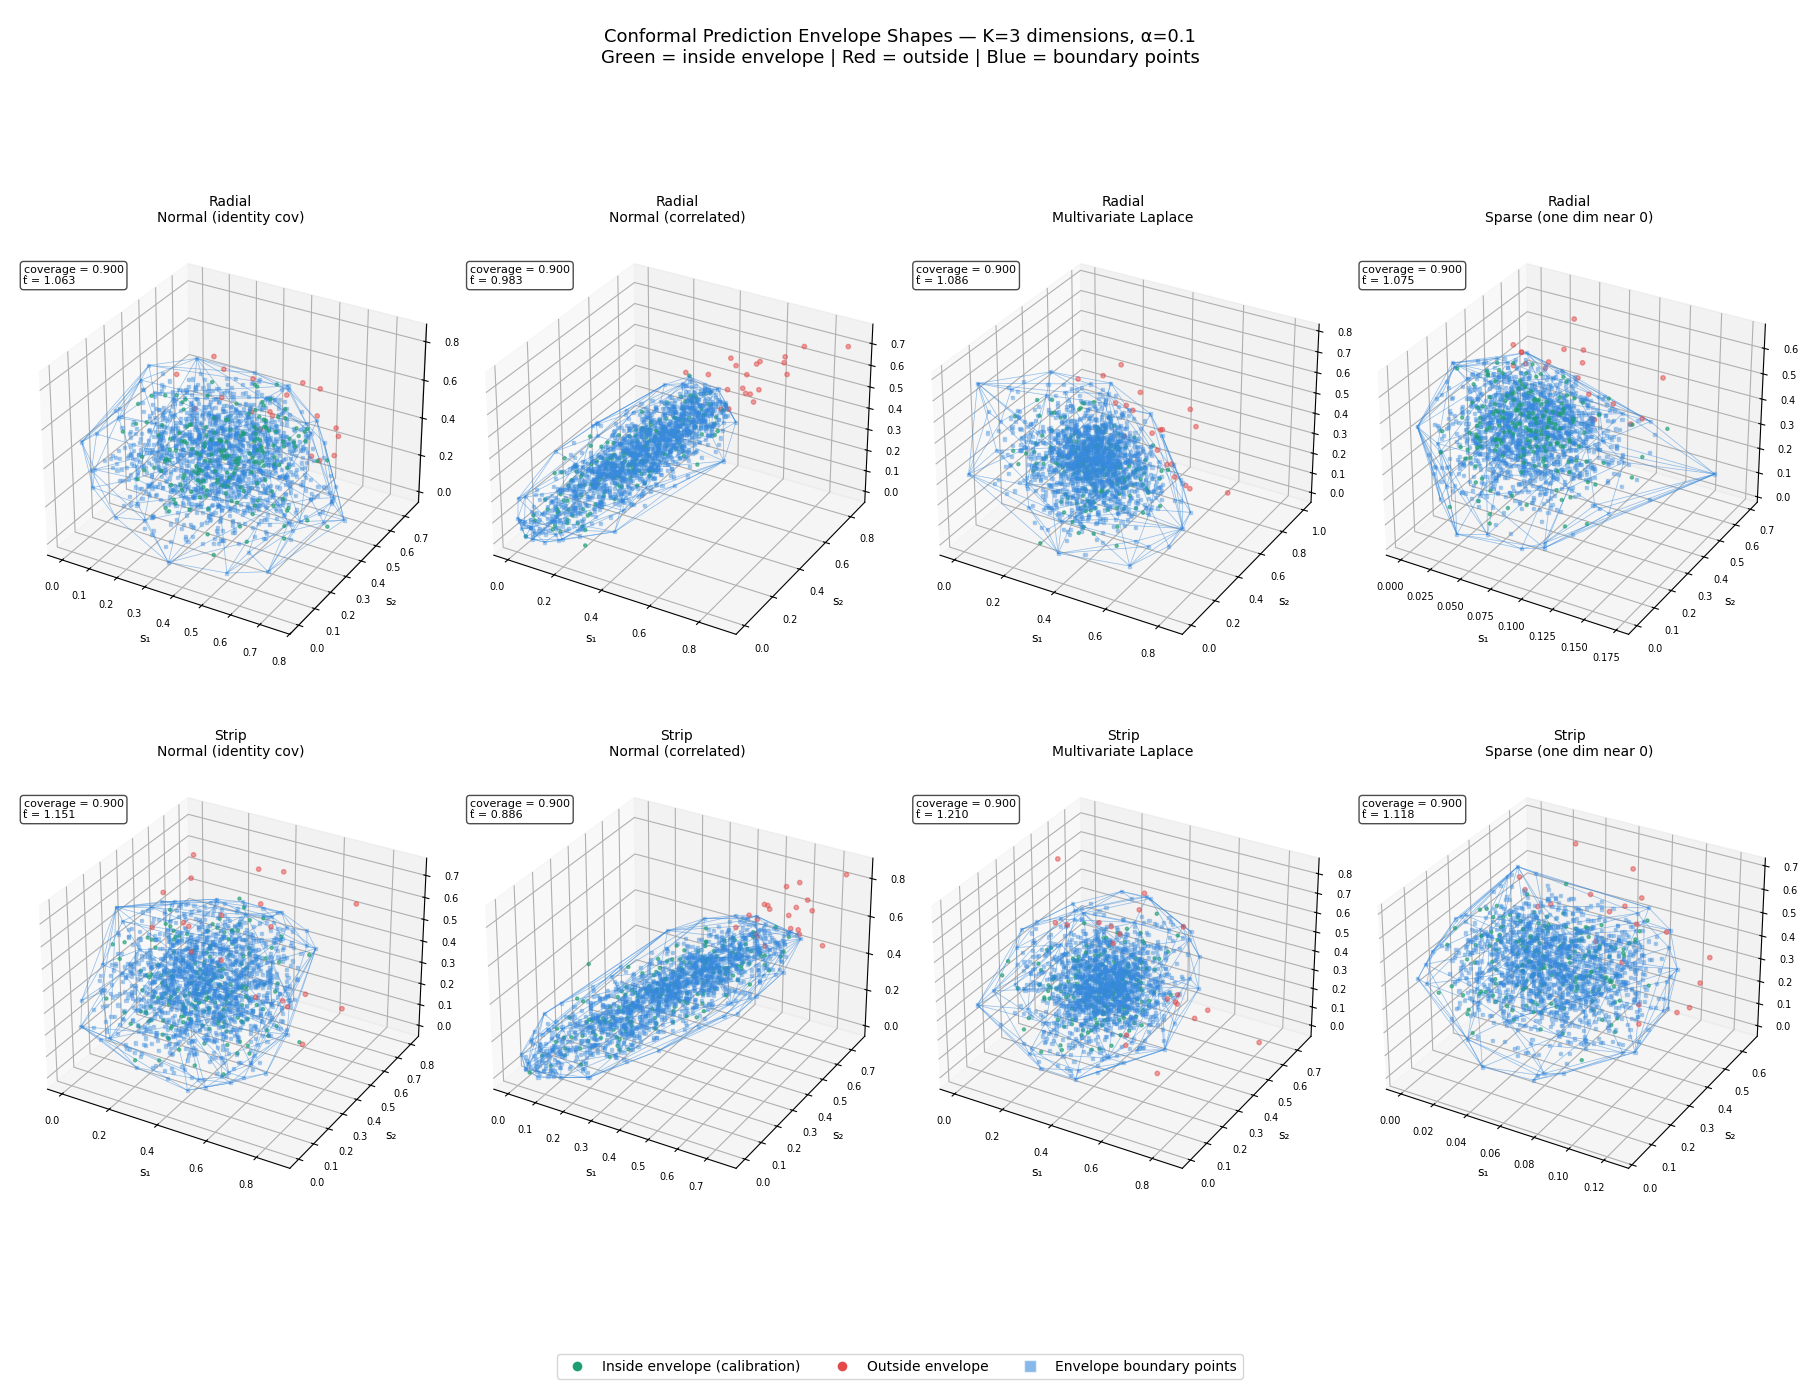

In [102]:
np.random.seed(13)
print_analysis(alpha=0.10, N=400)

fig = make_figure(alpha=0.10, N=400, M_radial=150, M_strip=12)
plt.show()